
# PD plots: frequentist vs Bayesian, with CDS-implied RN benchmark

This notebook builds six date-level plots using the files you specified:

1. Merton **risk-neutral** PD: Bayesian credible interval + Bayesian median + frequentist PD + CDS-implied PD
2. NIG **risk-neutral** PD: Bayesian credible interval + Bayesian median + frequentist PD + CDS-implied PD
3. Merton **physical** PD: Bayesian credible interval + Bayesian median + frequentist PD
4. NIG **physical** PD: Bayesian credible interval + Bayesian median + frequentist PD
5. **Merged risk-neutral** plot: Merton vs NIG, with CDS-implied PD
6. **Merged physical** plot: Merton vs NIG

Important note: the CDS benchmark is the **CDS-implied 1y PD** (`PD_1y_CDS_par` style), not raw CDS spreads. That matches the methodology used in your evaluation notebooks.


In [1]:

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)


In [2]:

# ------------------------------------------------------------------
# User choices
# ------------------------------------------------------------------
AGG = "mean"                 # "mean" or "median"
RECOVERY_RATE = 0.40
SHOW_CDS_ON_PHYSICAL = False  # kept False by default because CDS-implied PD is RN
SAVE_PLOTS = True
SAVE_PANELS = True

DROP_GVKEYS = {
    "241456",
    "101336",
    "17436",
    "201794",
    "220940",
    "100022",
    "221616",
    "61616",
    "101202",
}


In [3]:

# ------------------------------------------------------------------
# Path helpers
# ------------------------------------------------------------------

def resolve_path(*candidates):
    """Return the first existing path among candidate strings / Path objects."""
    expanded = []
    cwd = Path.cwd().resolve()
    for cand in candidates:
        cand = Path(cand)
        expanded.extend([
            cand,
            cwd / cand,
            cwd / ".." / cand,
            cwd / ".." / ".." / cand,
        ])
    seen = []
    for p in expanded:
        p = p.resolve()
        if p not in seen:
            seen.append(p)
    for p in seen:
        if p.exists():
            return p
    raise FileNotFoundError("None of these paths exist:".join(str(x) for x in seen))


def resolve_optional_path(*candidates):
    try:
        return resolve_path(*candidates)
    except FileNotFoundError:
        return None


merton_path = resolve_path("data/derived/merton_weekly.csv")
nig_path = resolve_path("data/derived/nig_freq.csv")
bayes_merton_path = resolve_optional_path(
    "data/derived/bayesian_merton_oos.csv",
    "data/derived/bayesian_merton_oos_weekly.csv",
)
bayes_nig_path = resolve_path(
    "data/derived/bayesian_nig/bayes_nig_oos_weekly_condfixA_iter4000_burn500_thin5_firms21_wins36.csv",
    "data/derived/bayes_nig_oos_weekly_condfixA_iter12000_burn2000_thin10_firms21_wins36.csv",
)
cds_path = resolve_path("data/derived/CDS_panel.csv")
rf_path = resolve_path("data/raw/ecb_yc_1y_aaa.csv")

output_dir = (resolve_path("data/derived") / "bayesian_interval_comparison" / "pd_plots_cds_implied")
output_dir.mkdir(parents=True, exist_ok=True)

print("merton      ->", merton_path)
print("nig         ->", nig_path)
print("bayes merton->", bayes_merton_path)
print("bayes nig   ->", bayes_nig_path)
print("cds         ->", cds_path)
print("rf          ->", rf_path)
print("output dir  ->", output_dir)


merton      -> C:\Users\afons\OneDrive\Desktop\ESE\FCS\Merton_NIGbayesian\data\derived\merton_weekly.csv
nig         -> C:\Users\afons\OneDrive\Desktop\ESE\FCS\Merton_NIGbayesian\data\derived\nig_freq.csv
bayes merton-> C:\Users\afons\OneDrive\Desktop\ESE\FCS\Merton_NIGbayesian\data\derived\bayesian_merton_oos_weekly.csv
bayes nig   -> C:\Users\afons\OneDrive\Desktop\ESE\FCS\Merton_NIGbayesian\data\derived\bayesian_nig\bayes_nig_oos_weekly_condfixA_iter4000_burn500_thin5_firms21_wins36.csv
cds         -> C:\Users\afons\OneDrive\Desktop\ESE\FCS\Merton_NIGbayesian\data\derived\CDS_panel.csv
rf          -> C:\Users\afons\OneDrive\Desktop\ESE\FCS\Merton_NIGbayesian\data\raw\ecb_yc_1y_aaa.csv
output dir  -> C:\Users\afons\OneDrive\Desktop\ESE\FCS\Merton_NIGbayesian\data\derived\bayesian_interval_comparison\pd_plots_cds_implied


In [4]:

# ------------------------------------------------------------------
# Load CSVs
# ------------------------------------------------------------------

merton = pd.read_csv(merton_path)
nig = pd.read_csv(nig_path)
bayes_merton = pd.read_csv(bayes_merton_path)
bayes_nig = pd.read_csv(bayes_nig_path)
cds = pd.read_csv(cds_path)
rf = pd.read_csv(rf_path)

print("merton columns:", list(merton.columns))
print("nig columns:", list(nig.columns))
print("bayes_merton columns:", list(bayes_merton.columns))
print("bayes_nig columns:", list(bayes_nig.columns))
print("cds columns:", list(cds.columns))
print("rf columns:", list(rf.columns))


merton columns: ['gvkey', 'date', 'sigma_hat', 'mu_hat', 'V_0', 'V_used', 'B_used', 'PD_Q', 'PD_P', 'train_start_date', 'train_end_date', 'training_end']
nig columns: ['date', 'window_idx', 'ok', 'msg', 'window_train_start', 'window_train_end', 'window_oos_start', 'window_oos_end', 'gvkey', 'A_hat_oos', 'theta_oos', 'L_proxy', 'PD_P', 'PD_Q', 'alpha', 'beta1', 'delta', 'beta0', 'em_converged', 'em_n_iter']
bayes_merton columns: ['gvkey', 'window_idx', 'date', 'rf_used', 'B_used', 'asset_lo', 'asset_med', 'asset_hi', 'asset_mean', 'PD_Q_lo', 'PD_Q_med', 'PD_Q_hi', 'PD_Q_mean', 'PD_P_lo', 'PD_P_med', 'PD_P_hi', 'PD_P_mean']
bayes_nig columns: ['date', 'gvkey', 'window_idx', 'rf_used', 'B_used', 'asset_lo', 'asset_med', 'asset_hi', 'asset_mean', 'asset_n_valid', 'PD_Q_lo', 'PD_Q_med', 'PD_Q_hi', 'PD_Q_mean', 'PD_Q_n_valid', 'PD_P_lo', 'PD_P_med', 'PD_P_hi', 'PD_P_mean', 'PD_P_n_valid', 'train_start', 'train_end', 'oos_start', 'oos_end']
cds columns: ['gvkey', 'date', 'cds']
rf columns: ['

In [5]:

# ------------------------------------------------------------------
# Standardize types and keep the usable rows
# ------------------------------------------------------------------

def standardize_panel(df, *, date_col="date", gvkey_col="gvkey"):
    out = df.copy()
    out[gvkey_col] = out[gvkey_col].astype(str)
    out[date_col] = pd.to_datetime(out[date_col], errors="coerce")
    out = out.dropna(subset=[gvkey_col, date_col]).copy()
    out = out.loc[~out[gvkey_col].isin(DROP_GVKEYS)].copy()
    return out

merton = standardize_panel(merton)
nig = standardize_panel(nig)
bayes_merton = standardize_panel(bayes_merton)
bayes_nig = standardize_panel(bayes_nig)
cds = standardize_panel(cds)
rf["date"] = pd.to_datetime(rf["date"], errors="coerce")

# frequentist cleanup
if "training_end" in merton.columns:
    merton = merton.loc[merton["training_end"].fillna(0).astype(int) == 0].copy()
if "ok" in nig.columns:
    nig = nig.loc[nig["ok"].fillna(False).astype(bool)].copy()

# risk-free rename/units to match your evaluation notebook
rf = rf.rename(columns={"r_1y": "r_f"}).copy()
rf["r_f"] = pd.to_numeric(rf["r_f"], errors="coerce")
if rf["r_f"].median(skipna=True) > 0.5:
    rf["r_f"] = rf["r_f"] / 100.0
rf = rf.dropna(subset=["date", "r_f"]).sort_values("date").reset_index(drop=True)

for name, df in [("merton", merton), ("nig", nig), ("bayes_merton", bayes_merton), ("bayes_nig", bayes_nig), ("cds", cds)]:
    print(f"{name:13s}: rows={len(df):6d} firms={df['gvkey'].nunique():2d} range={df['date'].min().date()} -> {df['date'].max().date()}")


merton       : rows= 14634 firms=27 range=2014-04-04 -> 2024-12-31
nig          : rows=  6550 firms=12 range=2014-04-04 -> 2024-12-27
bayes_merton : rows=  5832 firms=12 range=2016-01-01 -> 2024-12-31
bayes_nig    : rows=  5640 firms=12 range=2016-01-01 -> 2024-12-27
cds          : rows= 38993 firms=13 range=2014-01-01 -> 2025-12-31


In [6]:

# ------------------------------------------------------------------
# CDS-implied PD helpers (same idea as in your evaluation notebooks)
# ------------------------------------------------------------------

def _to_spread_decimal(cds_values, unit="auto"):
    x = pd.to_numeric(cds_values, errors="coerce").astype(float).to_numpy()
    med = np.nanmedian(x)
    if unit == "auto":
        unit = "bps" if med > 1.0 else "decimal"
    if unit == "bps":
        return x / 1e4
    if unit == "decimal":
        return x
    raise ValueError("unit must be 'bps', 'decimal', or 'auto'")


def cds_pd_par_1y_flat_hazard(
    cds_values,
    r=0.0,
    R=0.40,
    unit="auto",
    pay_freq=4,
    T=1.0,
    max_iter=60,
):
    """
    Flat-hazard single-tenor par-CDS calibration with accrual-on-default approximation.
    Returns (PD_1y, hazard).
    """
    S = _to_spread_decimal(cds_values, unit=unit)
    S = np.asarray(S, dtype=float)
    r = np.asarray(pd.to_numeric(r, errors="coerce"), dtype=float)

    n = len(S)
    out_pd = np.full(n, np.nan)
    out_hz = np.full(n, np.nan)

    delta = 1.0 / pay_freq
    t = np.arange(1, int(round(T * pay_freq)) + 1) * delta

    def fair_spread_minus_market(lam, spread, rate):
        P = np.exp(-rate * t)
        Q = np.exp(-lam * t)
        Q_prev = np.r_[1.0, Q[:-1]]

        premium_leg = np.sum(delta * P * Q)
        accrual = np.sum(0.5 * delta * P * (Q_prev - Q))
        protection_leg = np.sum(P * (Q_prev - Q))

        lhs = spread * (premium_leg + accrual)
        rhs = (1.0 - R) * protection_leg
        return lhs - rhs

    for i in range(n):
        spread = S[i]
        rate = r[i] if np.isfinite(r[i]) else 0.0
        if not np.isfinite(spread) or spread < 0:
            continue
        if spread == 0:
            out_pd[i] = 0.0
            out_hz[i] = 0.0
            continue

        lo, hi = 1e-10, 20.0
        f_lo = fair_spread_minus_market(lo, spread, rate)
        f_hi = fair_spread_minus_market(hi, spread, rate)

        k = 0
        while np.isfinite(f_lo) and np.isfinite(f_hi) and f_lo * f_hi > 0 and k < 20:
            hi *= 2.0
            f_hi = fair_spread_minus_market(hi, spread, rate)
            k += 1

        if not (np.isfinite(f_lo) and np.isfinite(f_hi)):
            continue

        if f_lo * f_hi > 0:
            lam = max(1e-12, spread / max(1e-12, (1.0 - R)))
        else:
            for _ in range(max_iter):
                mid = 0.5 * (lo + hi)
                f_mid = fair_spread_minus_market(mid, spread, rate)
                if not np.isfinite(f_mid):
                    break
                if f_lo * f_mid <= 0:
                    hi = mid
                    f_hi = f_mid
                else:
                    lo = mid
                    f_lo = f_mid
            lam = 0.5 * (lo + hi)

        out_hz[i] = lam
        out_pd[i] = 1.0 - np.exp(-lam * T)

    return out_pd, out_hz


In [7]:

# ------------------------------------------------------------------
# Attach CDS-implied PD benchmark to any weekly panel
# ------------------------------------------------------------------

def attach_cds_implied_pd(panel, cds_panel, rf_panel, *, cds_col="cds", benchmark_col="PD_1y_CDS_par"):
    left = panel.copy()
    left["gvkey"] = left["gvkey"].astype(str)
    left["date"] = pd.to_datetime(left["date"], errors="coerce")
    left = left.sort_values(["date", "gvkey"]).reset_index(drop=True)

    right_cds = cds_panel.copy()
    right_cds["gvkey"] = right_cds["gvkey"].astype(str)
    right_cds["date"] = pd.to_datetime(right_cds["date"], errors="coerce")
    right_cds[cds_col] = pd.to_numeric(right_cds[cds_col], errors="coerce")
    right_cds = right_cds.sort_values(["date", "gvkey"]).reset_index(drop=True)

    merged = pd.merge_asof(
        left,
        right_cds[["gvkey", "date", cds_col]],
        on="date",
        by="gvkey",
        direction="backward",
        allow_exact_matches=True,
    )

    merged = merged.sort_values("date").reset_index(drop=True)
    merged = pd.merge_asof(
        merged,
        rf_panel[["date", "r_f"]].sort_values("date").reset_index(drop=True),
        on="date",
        direction="backward",
        allow_exact_matches=True,
    )

    pd_1y, hazard = cds_pd_par_1y_flat_hazard(
        merged[cds_col],
        r=merged["r_f"],
        R=RECOVERY_RATE,
        unit="auto",
        pay_freq=4,
        T=1.0,
    )
    merged[benchmark_col] = pd_1y
    merged["haz_CDS_par"] = hazard
    return merged

merton_bench = attach_cds_implied_pd(merton, cds, rf)
nig_bench = attach_cds_implied_pd(nig, cds, rf)
bayes_merton_bench = attach_cds_implied_pd(bayes_merton, cds, rf)
bayes_nig_bench = attach_cds_implied_pd(bayes_nig, cds, rf)

for name, df in [("merton_bench", merton_bench), ("nig_bench", nig_bench), ("bayes_merton_bench", bayes_merton_bench), ("bayes_nig_bench", bayes_nig_bench)]:
    miss = df["PD_1y_CDS_par"].isna().mean()
    print(f"{name:18s}: missing CDS-implied PD share = {miss:.3%}")


merton_bench      : missing CDS-implied PD share = 55.556%
nig_bench         : missing CDS-implied PD share = 0.000%
bayes_merton_bench: missing CDS-implied PD share = 0.000%
bayes_nig_bench   : missing CDS-implied PD share = 0.000%


In [8]:

# ------------------------------------------------------------------
# Plot helpers
# ------------------------------------------------------------------

def aggregate_by_date(df, cols, agg=AGG):
    work = df[["date"] + cols].copy()
    work["date"] = pd.to_datetime(work["date"], errors="coerce")
    work = work.dropna(subset=["date"]).sort_values("date")
    if agg == "mean":
        out = work.groupby("date", as_index=False)[cols].mean(numeric_only=True)
    elif agg == "median":
        out = work.groupby("date", as_index=False)[cols].median(numeric_only=True)
    else:
        raise ValueError("AGG must be 'mean' or 'median'")
    return out.sort_values("date").reset_index(drop=True)


def prep_single_model_panel(freq_df, bayes_df, *, pd_kind, benchmark_for_q=True):
    # keep only the columns we need, then align on exact firm-date overlap
    freq_cols = ["gvkey", "date", f"PD_{pd_kind}"]
    bayes_cols = ["gvkey", "date", f"PD_{pd_kind}_lo", f"PD_{pd_kind}_med", f"PD_{pd_kind}_hi"]
    if benchmark_for_q:
        freq_cols.append("PD_1y_CDS_par")
        bayes_cols.append("PD_1y_CDS_par")

    freq_use = freq_df[freq_cols].copy()
    bayes_use = bayes_df[bayes_cols].copy()

    merged = freq_use.merge(bayes_use, on=["gvkey", "date"], how="inner", suffixes=("_freq", "_bayes"))

    rename_map = {
        f"PD_{pd_kind}": "freq_pd",
        f"PD_{pd_kind}_lo": "bayes_lo",
        f"PD_{pd_kind}_med": "bayes_med",
        f"PD_{pd_kind}_hi": "bayes_hi",
    }
    merged = merged.rename(columns=rename_map)

    if benchmark_for_q:
        bench_candidates = [c for c in merged.columns if c.startswith("PD_1y_CDS_par")]
        if bench_candidates:
            merged["cds_pd"] = merged[bench_candidates[0]]

    keep_cols = ["gvkey", "date", "freq_pd", "bayes_lo", "bayes_med", "bayes_hi"]
    if benchmark_for_q and "cds_pd" in merged.columns:
        keep_cols.append("cds_pd")
    return merged[keep_cols].copy()


def prep_merged_models_panel(pd_kind):
    q = pd_kind.upper() == "Q"
    base = merton_bench[["gvkey", "date", f"PD_{pd_kind}"]].rename(columns={f"PD_{pd_kind}": "merton_freq"})
    base = base.merge(
        bayes_merton_bench[["gvkey", "date", f"PD_{pd_kind}_lo", f"PD_{pd_kind}_med", f"PD_{pd_kind}_hi"]].rename(
            columns={f"PD_{pd_kind}_lo": "merton_bayes_lo", f"PD_{pd_kind}_med": "merton_bayes_med", f"PD_{pd_kind}_hi": "merton_bayes_hi"}
        ),
        on=["gvkey", "date"], how="inner"
    )
    base = base.merge(
        nig_bench[["gvkey", "date", f"PD_{pd_kind}"]].rename(columns={f"PD_{pd_kind}": "nig_freq"}),
        on=["gvkey", "date"], how="inner"
    )
    base = base.merge(
        bayes_nig_bench[["gvkey", "date", f"PD_{pd_kind}_lo", f"PD_{pd_kind}_med", f"PD_{pd_kind}_hi"]].rename(
            columns={f"PD_{pd_kind}_lo": "nig_bayes_lo", f"PD_{pd_kind}_med": "nig_bayes_med", f"PD_{pd_kind}_hi": "nig_bayes_hi"}
        ),
        on=["gvkey", "date"], how="inner"
    )

    if q:
        bench = bayes_nig_bench[["gvkey", "date", "PD_1y_CDS_par"]].copy()
        base = base.merge(bench, on=["gvkey", "date"], how="left")
        base = base.rename(columns={"PD_1y_CDS_par": "cds_pd"})

    return base.sort_values(["date", "gvkey"]).reset_index(drop=True)


def save_plot(fig, filename):
    if SAVE_PLOTS:
        fig.savefig(output_dir / filename, dpi=200, bbox_inches="tight")


def plot_single_model(single_panel, *, title, ylabel, include_cds=False, cds_on_physical=False):
    cols = ["freq_pd", "bayes_lo", "bayes_med", "bayes_hi"]
    if include_cds and "cds_pd" in single_panel.columns:
        cols.append("cds_pd")
    agg_df = aggregate_by_date(single_panel, cols)

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.fill_between(agg_df["date"], agg_df["bayes_lo"], agg_df["bayes_hi"], alpha=0.25, label="Bayesian credible interval")
    ax.plot(agg_df["date"], agg_df["bayes_med"], label="Bayesian median")
    ax.plot(agg_df["date"], agg_df["freq_pd"], linestyle="--", label="Frequentist PD")
    if include_cds and "cds_pd" in agg_df.columns:
        label = "CDS-implied PD (RN)"
        if cds_on_physical:
            label += ""
        ax.plot(agg_df["date"], agg_df["cds_pd"], linestyle=":", linewidth=2, label=label)
    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.tick_params(axis="x", rotation=45)
    fig.tight_layout()
    return fig, agg_df


def plot_merged_models(merged_panel, *, title, ylabel, include_cds=False):
    cols = [
        "merton_freq", "merton_bayes_lo", "merton_bayes_med", "merton_bayes_hi",
        "nig_freq", "nig_bayes_lo", "nig_bayes_med", "nig_bayes_hi",
    ]
    if include_cds and "cds_pd" in merged_panel.columns:
        cols.append("cds_pd")
    agg_df = aggregate_by_date(merged_panel, cols)

    fig, ax = plt.subplots(figsize=(15, 6))
    ax.fill_between(agg_df["date"], agg_df["merton_bayes_lo"], agg_df["merton_bayes_hi"], alpha=0.18, label="Merton Bayesian interval")
    ax.plot(agg_df["date"], agg_df["merton_bayes_med"], label="Merton Bayesian median")
    ax.plot(agg_df["date"], agg_df["merton_freq"], linestyle="--", label="Merton frequentist")

    ax.fill_between(agg_df["date"], agg_df["nig_bayes_lo"], agg_df["nig_bayes_hi"], alpha=0.18, label="NIG Bayesian interval")
    ax.plot(agg_df["date"], agg_df["nig_bayes_med"], label="NIG Bayesian median")
    ax.plot(agg_df["date"], agg_df["nig_freq"], linestyle="--", label="NIG frequentist")

    if include_cds and "cds_pd" in agg_df.columns:
        ax.plot(agg_df["date"], agg_df["cds_pd"], linestyle=":", linewidth=2, label="CDS-implied PD (RN)")

    ax.set_title(title)
    ax.set_xlabel("Date")
    ax.set_ylabel(ylabel)
    ax.legend(ncol=2)
    ax.tick_params(axis="x", rotation=45)
    fig.tight_layout()
    return fig, agg_df


In [9]:

# ------------------------------------------------------------------
# Build aligned panels
# ------------------------------------------------------------------

merton_q_panel = prep_single_model_panel(merton_bench, bayes_merton_bench, pd_kind="Q", benchmark_for_q=True)
nig_q_panel = prep_single_model_panel(nig_bench, bayes_nig_bench, pd_kind="Q", benchmark_for_q=True)
merton_p_panel = prep_single_model_panel(merton_bench, bayes_merton_bench, pd_kind="P", benchmark_for_q=False)
nig_p_panel = prep_single_model_panel(nig_bench, bayes_nig_bench, pd_kind="P", benchmark_for_q=False)

merged_q_panel = prep_merged_models_panel("Q")
merged_p_panel = prep_merged_models_panel("P")

for name, df in [
    ("merton_q_panel", merton_q_panel),
    ("nig_q_panel", nig_q_panel),
    ("merton_p_panel", merton_p_panel),
    ("nig_p_panel", nig_p_panel),
    ("merged_q_panel", merged_q_panel),
    ("merged_p_panel", merged_p_panel),
]:
    print(f"{name:15s}: rows={len(df):6d} firms={df['gvkey'].nunique():2d} range={df['date'].min().date()} -> {df['date'].max().date()}")


merton_q_panel : rows=  5412 firms=12 range=2016-01-01 -> 2024-12-31
nig_q_panel    : rows=  5640 firms=12 range=2016-01-01 -> 2024-12-27
merton_p_panel : rows=  5412 firms=12 range=2016-01-01 -> 2024-12-31
nig_p_panel    : rows=  5640 firms=12 range=2016-01-01 -> 2024-12-27
merged_q_panel : rows=  5400 firms=12 range=2016-01-01 -> 2024-12-27
merged_p_panel : rows=  5400 firms=12 range=2016-01-01 -> 2024-12-27


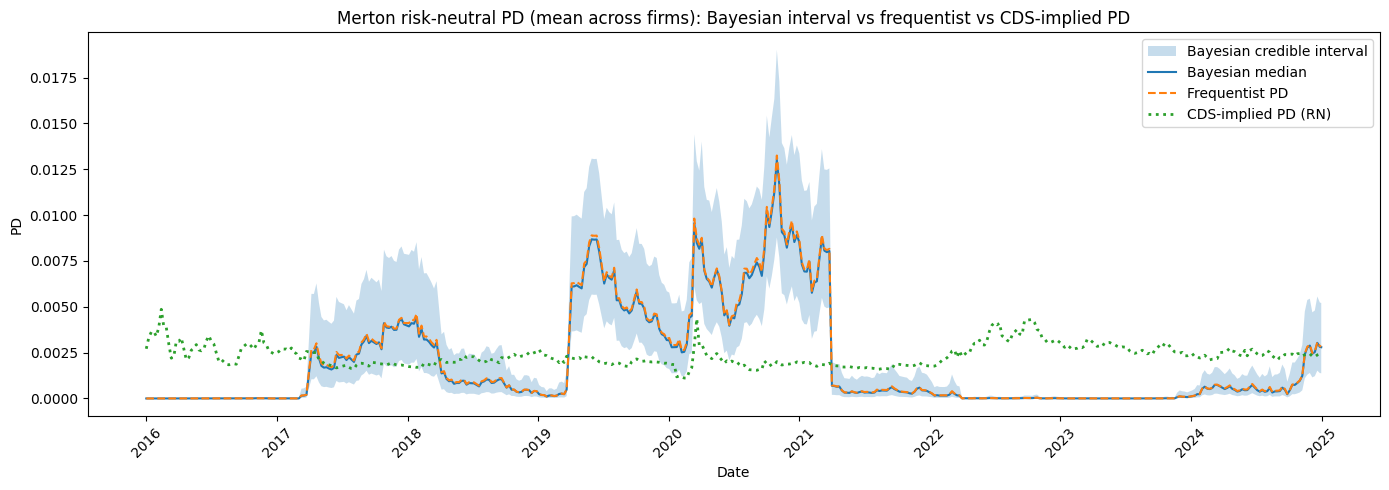

In [10]:

# ------------------------------------------------------------------
# Plot 1 — Merton risk-neutral
# ------------------------------------------------------------------
fig1, agg1 = plot_single_model(
    merton_q_panel,
    title=f"Merton risk-neutral PD ({AGG} across firms): Bayesian interval vs frequentist vs CDS-implied PD",
    ylabel="PD",
    include_cds=True,
)
plt.show()
save_plot(fig1, "01_merton_rn_with_cds_implied.png")


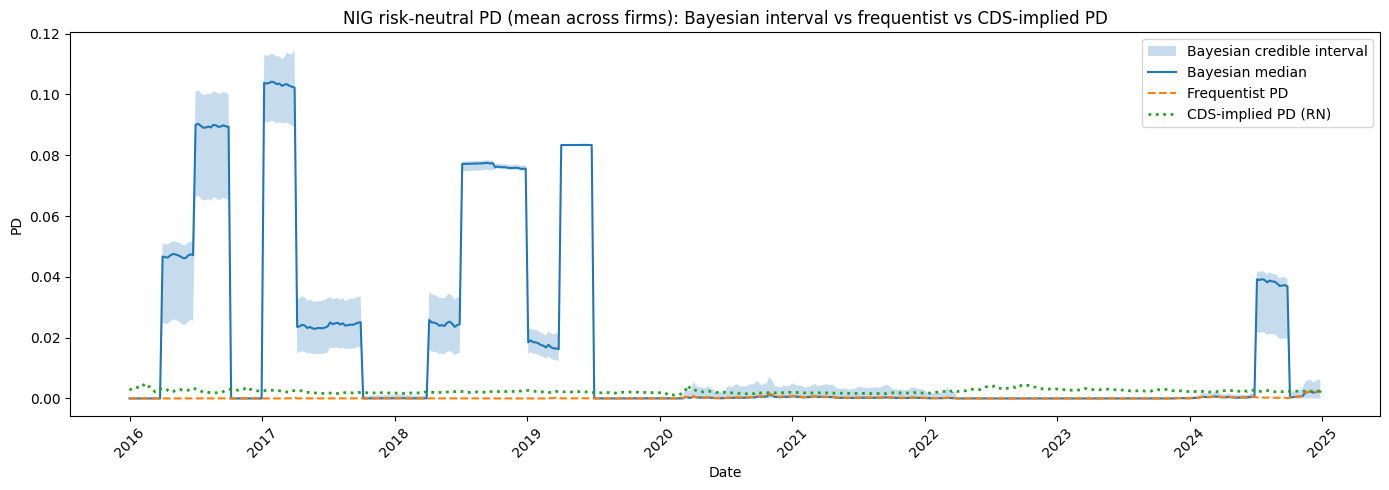

In [11]:

# ------------------------------------------------------------------
# Plot 2 — NIG risk-neutral
# ------------------------------------------------------------------
fig2, agg2 = plot_single_model(
    nig_q_panel,
    title=f"NIG risk-neutral PD ({AGG} across firms): Bayesian interval vs frequentist vs CDS-implied PD",
    ylabel="PD",
    include_cds=True,
)
plt.show()
save_plot(fig2, "02_nig_rn_with_cds_implied.png")


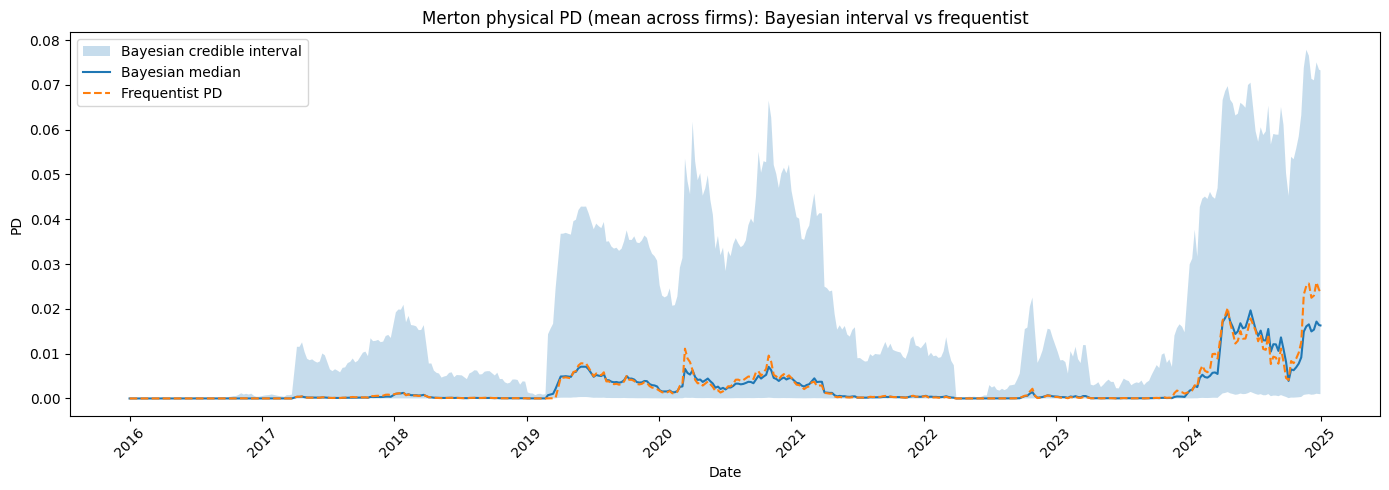

In [12]:

# ------------------------------------------------------------------
# Plot 3 — Merton physical
# ------------------------------------------------------------------
fig3, agg3 = plot_single_model(
    merton_p_panel,
    title=f"Merton physical PD ({AGG} across firms): Bayesian interval vs frequentist",
    ylabel="PD",
    include_cds=SHOW_CDS_ON_PHYSICAL,
    cds_on_physical=SHOW_CDS_ON_PHYSICAL,
)
plt.show()
save_plot(fig3, "03_merton_physical.png")


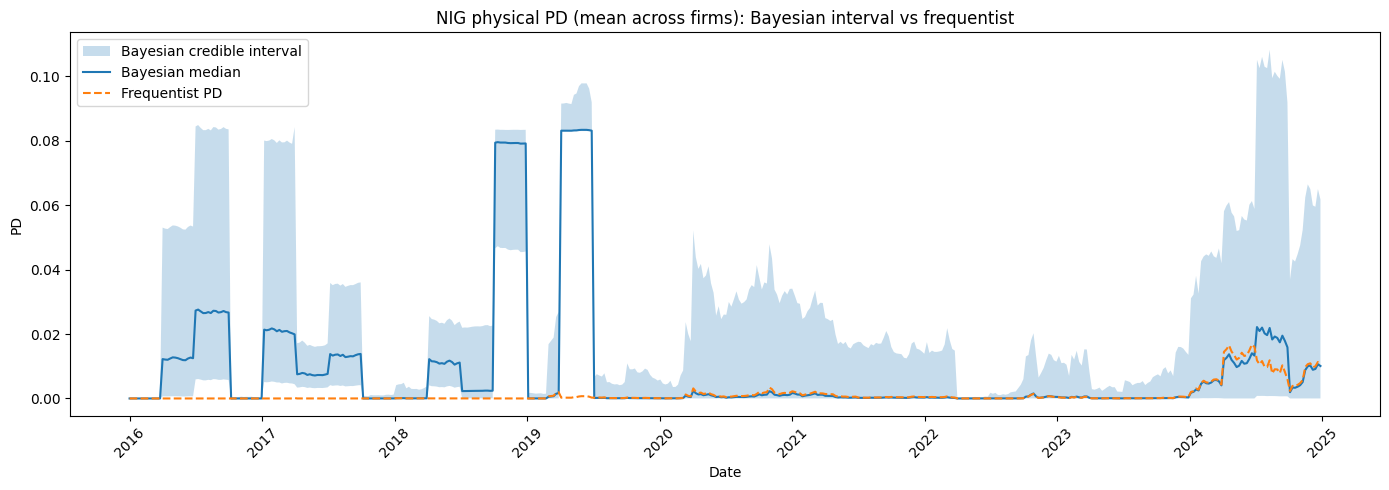

In [13]:

# ------------------------------------------------------------------
# Plot 4 — NIG physical
# ------------------------------------------------------------------
fig4, agg4 = plot_single_model(
    nig_p_panel,
    title=f"NIG physical PD ({AGG} across firms): Bayesian interval vs frequentist",
    ylabel="PD",
    include_cds=SHOW_CDS_ON_PHYSICAL,
    cds_on_physical=SHOW_CDS_ON_PHYSICAL,
)
plt.show()
save_plot(fig4, "04_nig_physical.png")


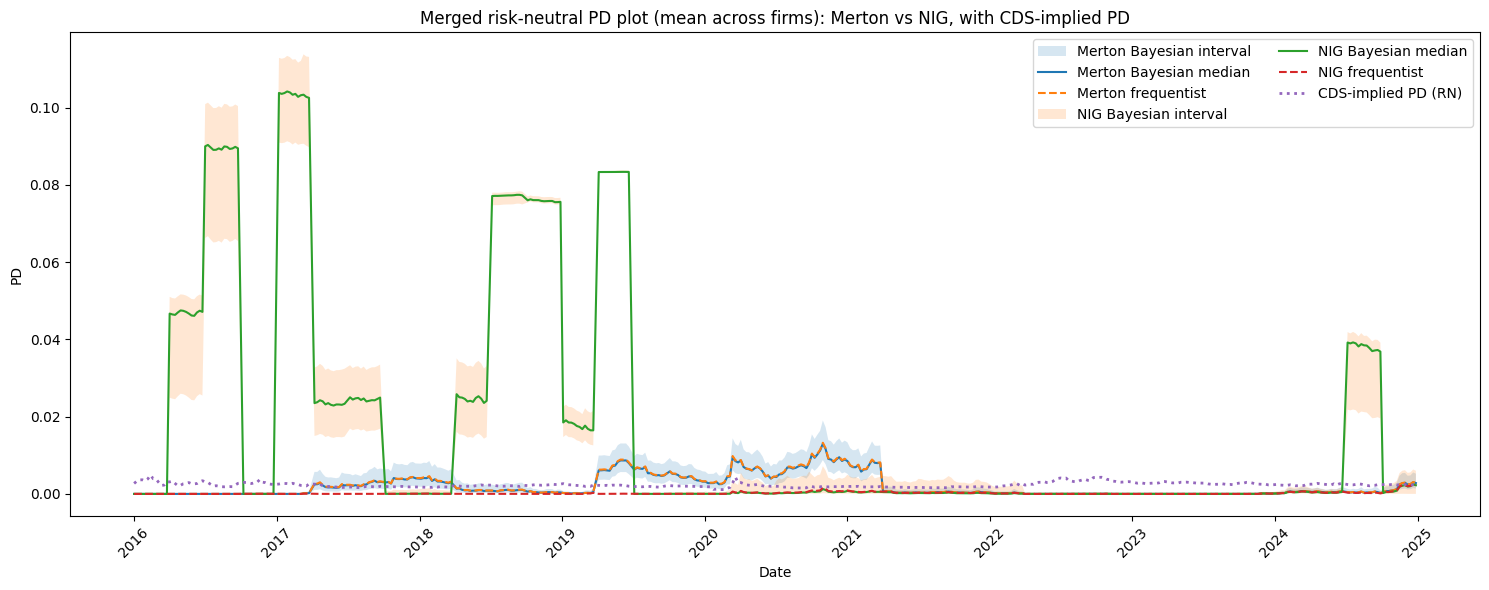

In [14]:

# ------------------------------------------------------------------
# Plot 5 — merged risk-neutral
# ------------------------------------------------------------------
fig5, agg5 = plot_merged_models(
    merged_q_panel,
    title=f"Merged risk-neutral PD plot ({AGG} across firms): Merton vs NIG, with CDS-implied PD",
    ylabel="PD",
    include_cds=True,
)
plt.show()
save_plot(fig5, "05_merged_rn_with_cds_implied.png")


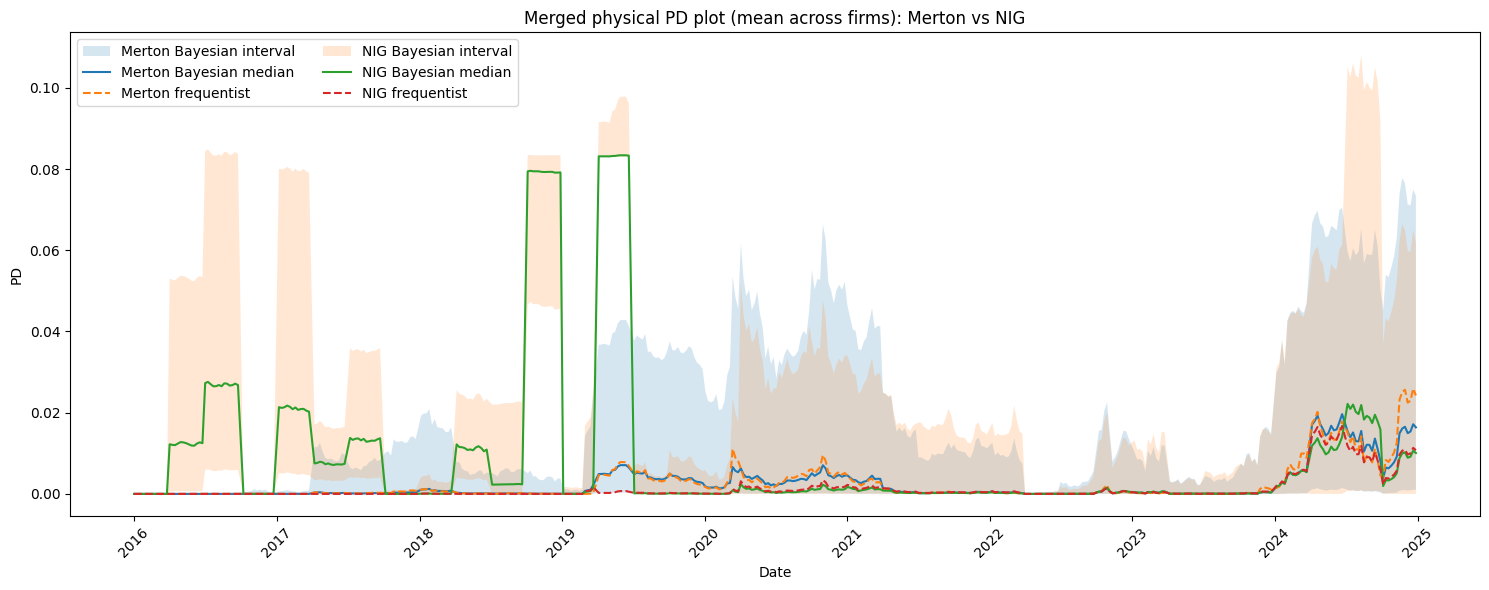

In [15]:

# ------------------------------------------------------------------
# Plot 6 — merged physical
# ------------------------------------------------------------------
fig6, agg6 = plot_merged_models(
    merged_p_panel,
    title=f"Merged physical PD plot ({AGG} across firms): Merton vs NIG",
    ylabel="PD",
    include_cds=False,
)
plt.show()
save_plot(fig6, "06_merged_physical.png")


In [16]:

# ------------------------------------------------------------------
# Optional: save the aggregated plotting panels
# ------------------------------------------------------------------
if SAVE_PANELS:
    agg1.to_csv(output_dir / "agg_01_merton_rn_with_cds_implied.csv", index=False)
    agg2.to_csv(output_dir / "agg_02_nig_rn_with_cds_implied.csv", index=False)
    agg3.to_csv(output_dir / "agg_03_merton_physical.csv", index=False)
    agg4.to_csv(output_dir / "agg_04_nig_physical.csv", index=False)
    agg5.to_csv(output_dir / "agg_05_merged_rn_with_cds_implied.csv", index=False)
    agg6.to_csv(output_dir / "agg_06_merged_physical.csv", index=False)

print("Saved outputs to:", output_dir)


Saved outputs to: C:\Users\afons\OneDrive\Desktop\ESE\FCS\Merton_NIGbayesian\data\derived\bayesian_interval_comparison\pd_plots_cds_implied


In [17]:

# quick preview of one aggregated panel
agg5.head()


,date,merton_freq,merton_bayes_lo,merton_bayes_med,merton_bayes_hi,nig_freq,nig_bayes_lo,nig_bayes_med,nig_bayes_hi,cds_pd
0,2016-01-01,4.764868e-08,8.297733e-10,3.600935e-08,0.000001,4.322347e-08,7.907310e-12,8.899014e-09,0.000009,0.002709
1,2016-01-08,1.830609e-07,5.416045e-09,1.434510e-07,0.000003,9.447916e-09,3.406679e-11,6.586385e-09,0.000002,0.003315
2,2016-01-15,2.867049e-07,9.711230e-09,2.267698e-07,0.000004,1.442349e-08,6.775234e-11,1.016480e-08,0.000002,0.003620
3,2016-01-22,1.523921e-07,4.226944e-09,1.189299e-07,0.000003,8.428199e-09,2.641693e-11,5.938743e-09,0.000001,0.003658
4,2016-01-29,1.728207e-07,5.387234e-09,1.359251e-07,0.000003,4.070178e-09,2.357977e-11,2.384067e-09,0.000001,0.003390
